In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("wine_data.csv", header=None, usecols=[0, 1, 2])
df.columns = ["Class label", "Alcohol", "Malic acid"]
df

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

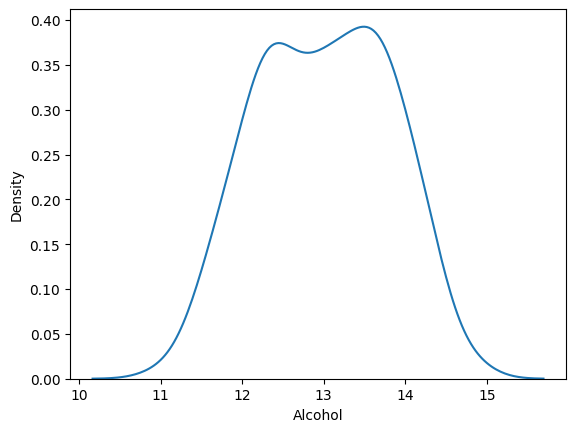

In [3]:
sns.kdeplot(df["Alcohol"])

<Axes: xlabel='Malic acid', ylabel='Density'>

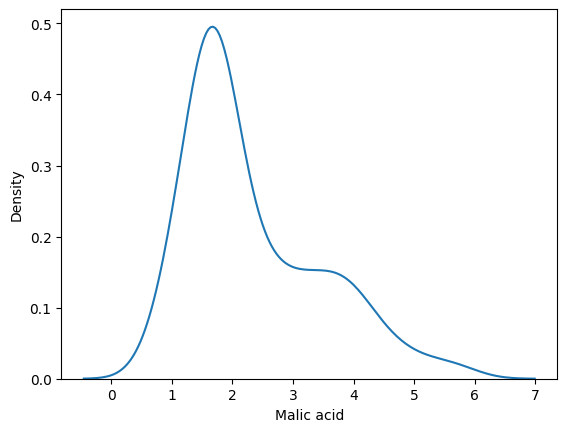

In [4]:
sns.kdeplot(df["Malic acid"])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

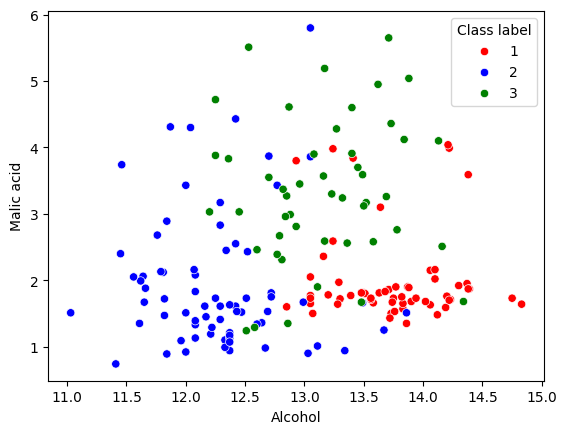

In [5]:
sns.scatterplot(x=df["Alcohol"], y=df["Malic acid"], hue=df["Class label"], palette=["red", "blue","green"])

**Train Test Split**

In [6]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df.drop("Class label", axis=1), 
                                                    df["Class label"], random_state=0,test_size=0.3)

In [7]:
x_train

,Alcohol,Malic acid
22,13.71,1.86
108,12.22,1.29
175,13.27,4.28
145,13.16,3.57
71,13.86,1.51
...,...,...
103,11.82,1.72
67,12.37,1.17
117,12.42,1.61
47,13.90,1.68


In [8]:
y_train

22     1
108    2
175    3
145    3
71     2
      ..
103    2
67     2
117    2
47     1
172    3
Name: Class label, Length: 124, dtype: int64

In [9]:
x_test

,Alcohol,Malic acid
54,13.74,1.67
151,12.79,2.67
63,12.37,1.13
55,13.56,1.73
123,13.05,5.80
121,11.56,2.05
7,14.06,2.15
160,12.36,3.83
106,12.25,1.73
90,12.08,1.83


In [10]:
y_test

54     1
151    3
63     2
55     1
123    2
121    2
7      1
160    3
106    2
90     2
141    3
146    3
5      1
98     2
168    3
80     2
33     1
18     1
61     2
51     1
66     2
37     1
4      1
104    2
60     2
111    2
126    2
86     2
112    2
164    3
26     1
56     1
129    2
45     1
8      1
44     1
161    3
92     2
94     2
174    3
24     1
30     1
93     2
101    2
113    2
19     1
135    3
74     2
144    3
16     1
131    3
138    3
40     1
158    3
Name: Class label, dtype: int64

**Min-Max Scaling**

In [11]:
from sklearn.preprocessing import MinMaxScaler
scalar = MinMaxScaler()

# Fit the scalar to the train set, it will learn the parameters
scalar.fit(x_train)

# Transform train and test 
x_train_scaled = scalar.transform(x_train)
x_test_scaled = scalar.transform(x_test)

In [12]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

In [13]:
x_train_scaled

,Alcohol,Malic acid
0,0.720430,0.203782
1,0.319892,0.084034
2,0.602151,0.712185
3,0.572581,0.563025
4,0.760753,0.130252
...,...,...
119,0.212366,0.174370
120,0.360215,0.058824
121,0.373656,0.151261
122,0.771505,0.165966


In [14]:
x_test_scaled

,Alcohol,Malic acid
0,0.728495,0.163866
1,0.473118,0.373950
2,0.360215,0.050420
3,0.680108,0.176471
4,0.543011,1.031513
5,0.142473,0.243697
6,0.814516,0.264706
7,0.357527,0.617647
8,0.327957,0.176471
9,0.282258,0.197479


In [15]:
x_train.describe()

,Alcohol,Malic acid
count,124.000000,124.000000
mean,12.983065,2.383710
std,0.801340,1.136696
min,11.030000,0.890000
25%,12.362500,1.607500
50%,13.040000,1.885000
75%,13.640000,3.247500
max,14.750000,5.650000


In [16]:
x_train_scaled.describe()

,Alcohol,Malic acid
count,124.000000,124.000000
mean,0.525017,0.313805
std,0.215414,0.238802
min,0.000000,0.000000
25%,0.358199,0.150735
50%,0.540323,0.209034
75%,0.701613,0.495273
max,1.000000,1.000000


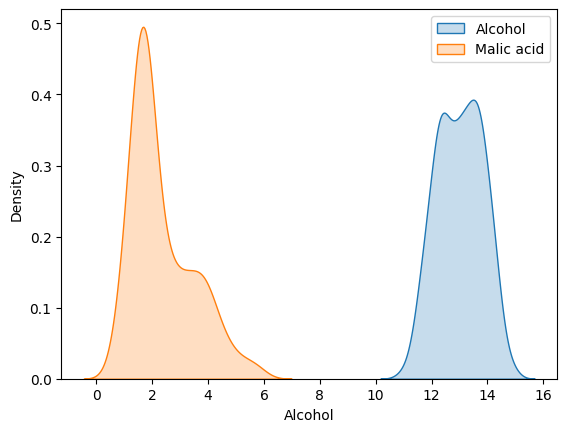

In [ ]:
# Before Transformation
sns.kdeplot(data=df, x="Alcohol", label="Alcohol", fill=True)
sns.kdeplot(data=df, x="Malic acid", label="Malic acid", fill=True)

plt.legend()
plt.show()

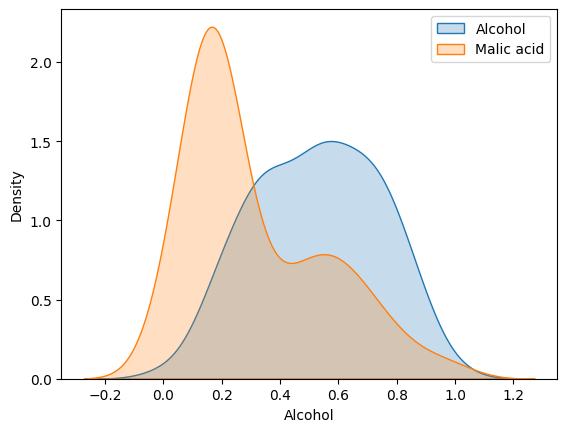

In [24]:
# After tranformation
sns.kdeplot(x_train_scaled['Alcohol'], label="Alcohol", fill=True)
sns.kdeplot(x_train_scaled['Malic acid'], label="Malic acid", fill=True)

plt.legend()
plt.show()